In [5]:
pip install opencv-python 


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install matplotlib 

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 17.5 MB/s eta 0:00:00 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.1
    Uninstalling numpy-2.4.1:
      Successfully uninstalled numpy-2.4.1
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikit-image

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", size=(5,5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

Matplotlib is building the font cache; this may take a moment.


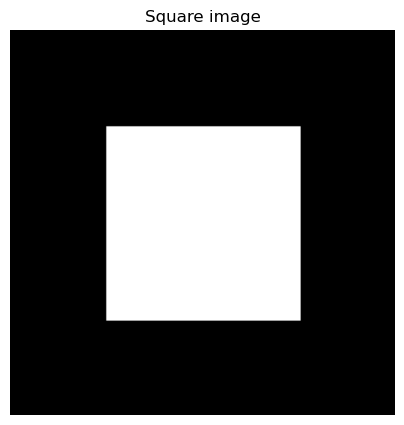

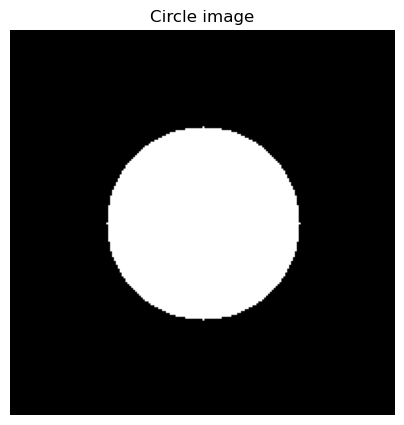

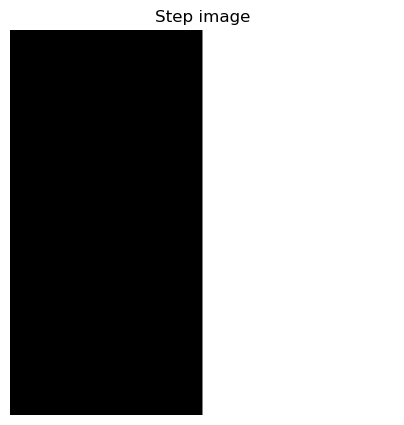

In [2]:
# Black background
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

# Draw shapes
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

# Create a step image: left side dark, right side bright
img_step[:, :100] = 50
img_step[:, 100:] = 220

show(img_square, "Square image")
show(img_circle, "Circle image")
show(img_step, "Step image")

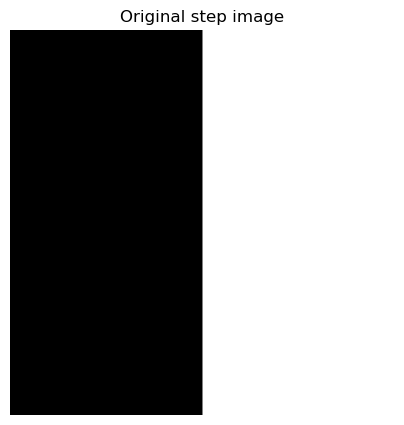

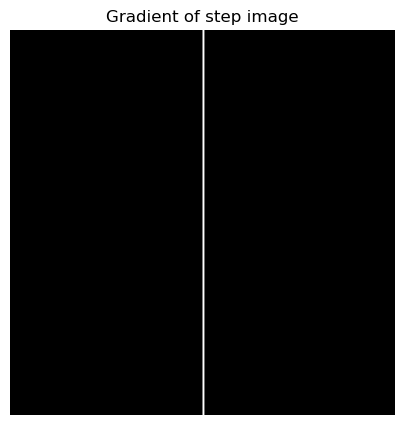

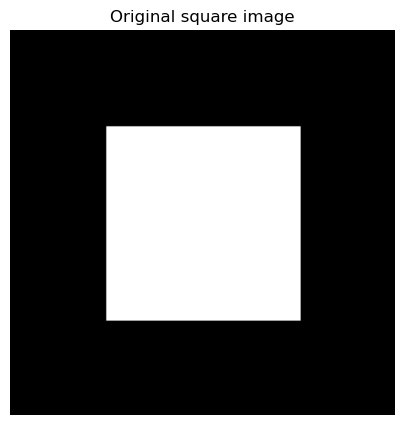

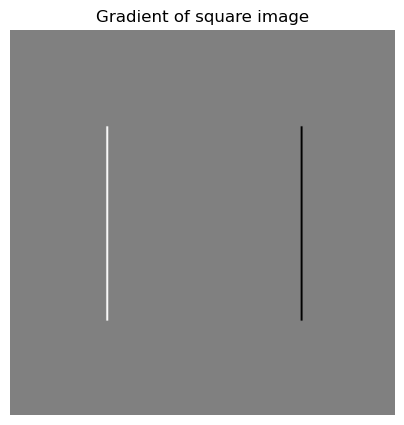

In [3]:
# Simple horizontal gradient kernel
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show(img_step, "Original step image")
show(grad_step, "Gradient of step image")
show(img_square, "Original square image")
show(grad_square, "Gradient of square image")

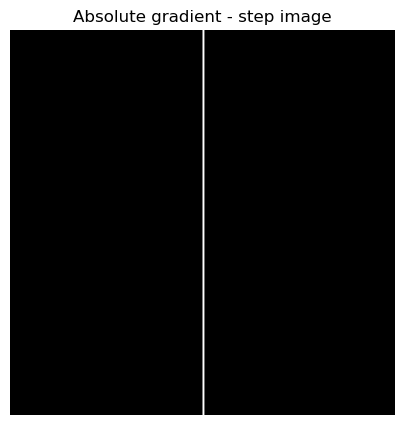

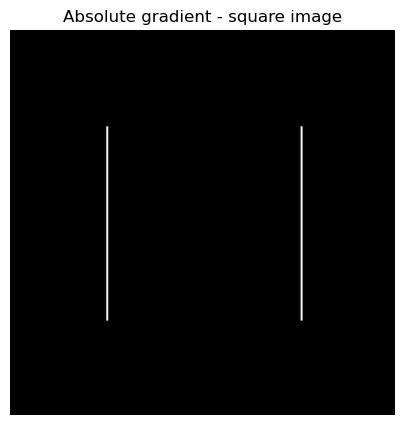

In [4]:
# Convert the gradient to absolute values for easier display
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show(grad_step_abs, "Absolute gradient - step image")
show(grad_square_abs, "Absolute gradient - square image")

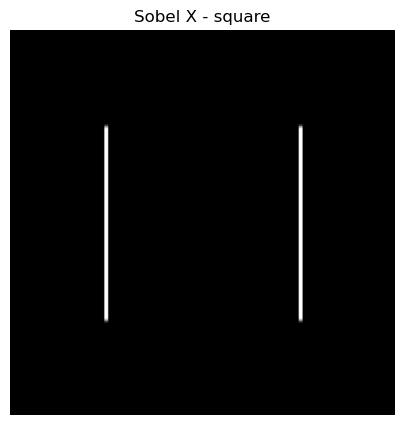

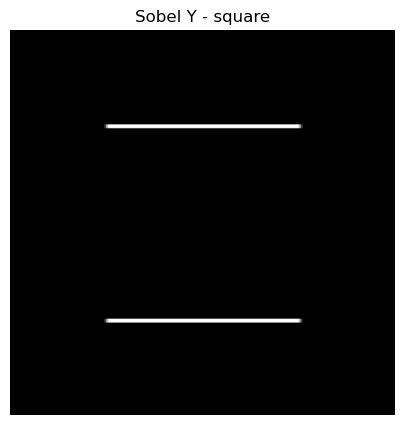

In [5]:
# Sobel in x and y directions
sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_x), "Sobel X - square")
show(np.abs(sobel_y), "Sobel Y - square")

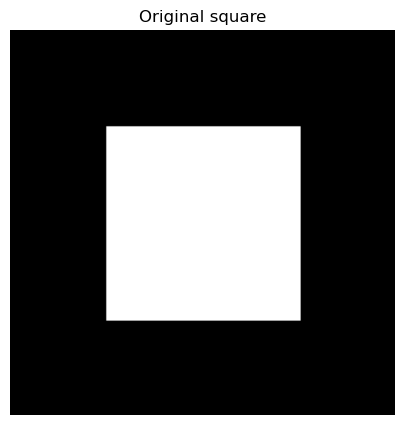

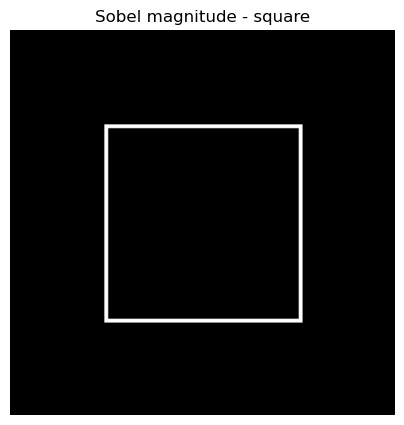

In [6]:
# Gradient magnitude from Sobel x and y
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

show(img_square, "Original square")
show(sobel_mag, "Sobel magnitude - square")

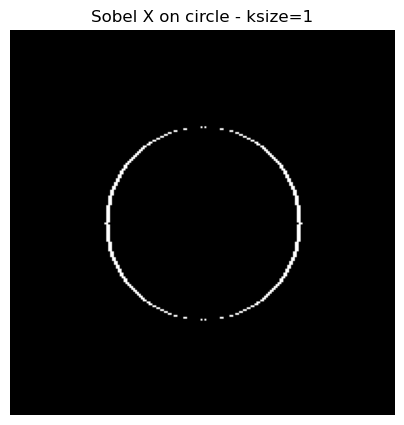

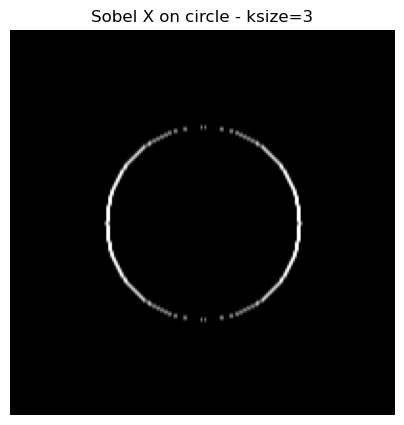

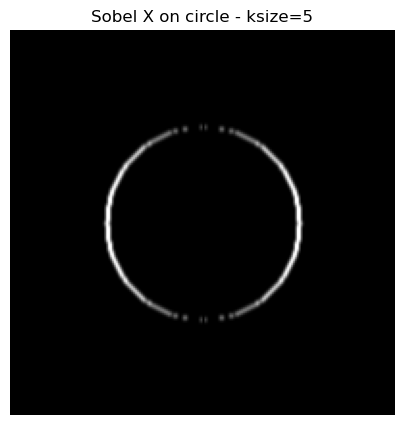

In [7]:
# Compare Sobel with different kernel sizes
for k in [1, 3, 5]:
    sobel_k = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=k)
    show(np.abs(sobel_k), f"Sobel X on circle - ksize={k}")

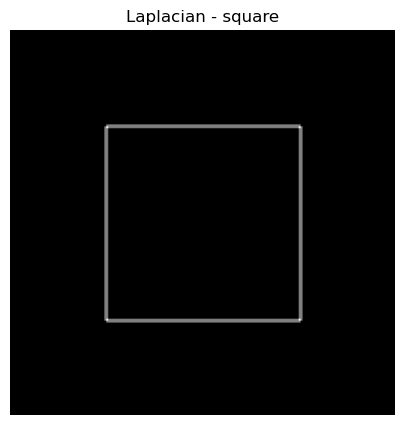

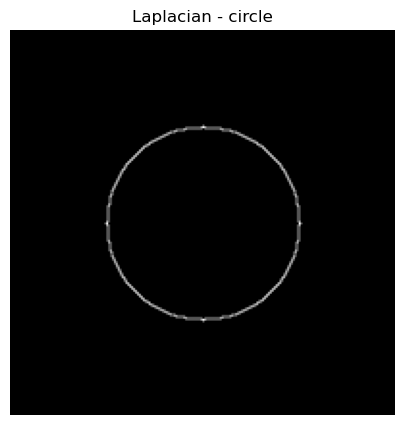

In [8]:
lap_square = cv2.Laplacian(img_square, cv2.CV_64F)
lap_circle = cv2.Laplacian(img_circle, cv2.CV_64F)

show(np.abs(lap_square), "Laplacian - square")
show(np.abs(lap_circle), "Laplacian - circle")

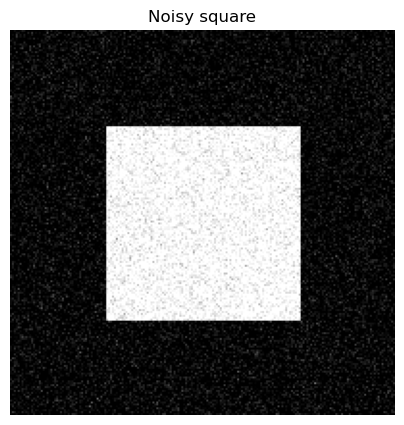

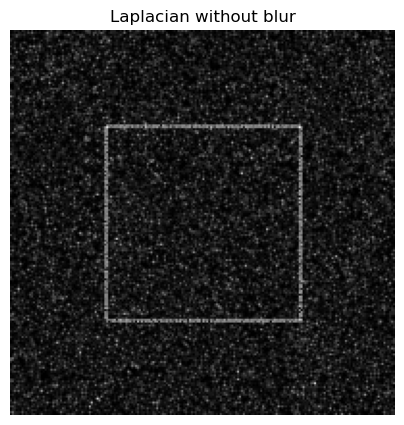

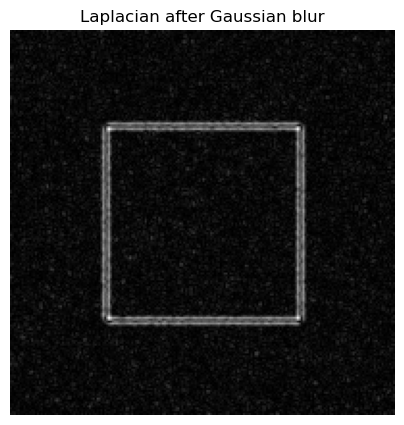

In [9]:
# Add noise to the square image
rng = np.random.default_rng(0)
noise = rng.normal(0, 25, img_square.shape)
img_square_noisy = np.clip(img_square + noise, 0, 255).astype(np.uint8)

# Laplacian without blur
lap_no_blur = cv2.Laplacian(img_square_noisy, cv2.CV_64F)

# Laplacian with Gaussian blur
img_square_blur = cv2.GaussianBlur(img_square_noisy, (5, 5), 0)
lap_blur = cv2.Laplacian(img_square_blur, cv2.CV_64F)

show(img_square_noisy, "Noisy square")
show(np.abs(lap_no_blur), "Laplacian without blur")
show(np.abs(lap_blur), "Laplacian after Gaussian blur")

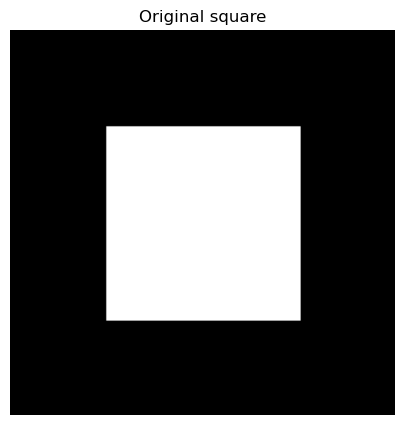

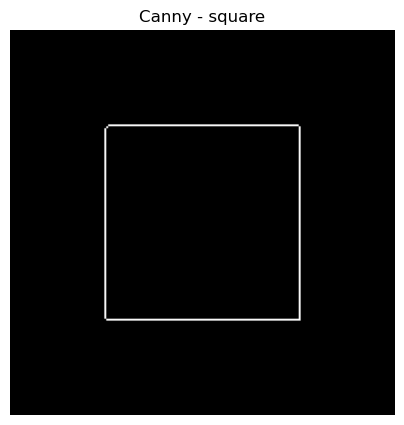

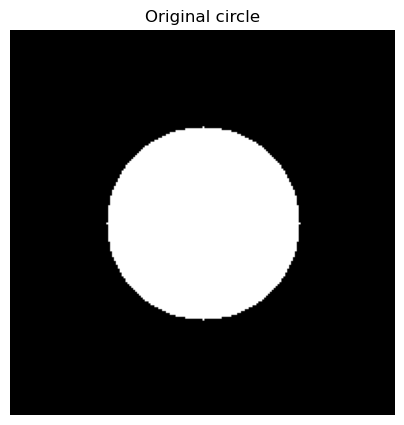

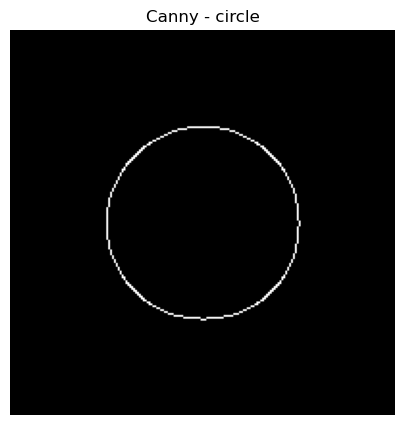

In [10]:
edges1 = cv2.Canny(img_square, 50, 150)
edges2 = cv2.Canny(img_circle, 50, 150)

show(img_square, "Original square")
show(edges1, "Canny - square")
show(img_circle, "Original circle")
show(edges2, "Canny - circle")

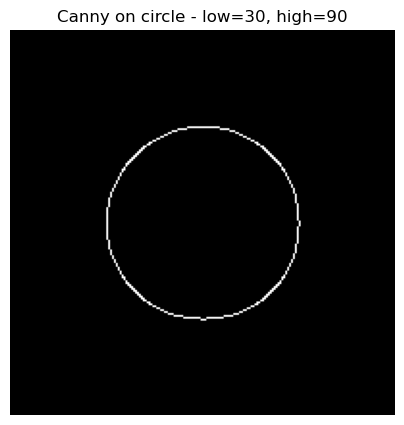

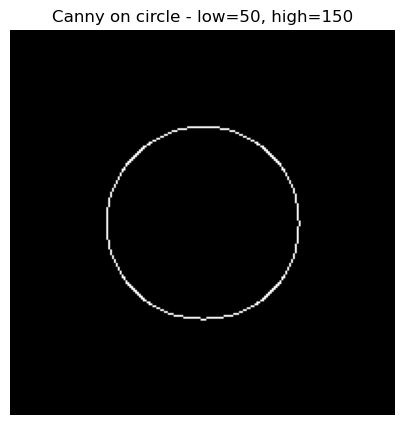

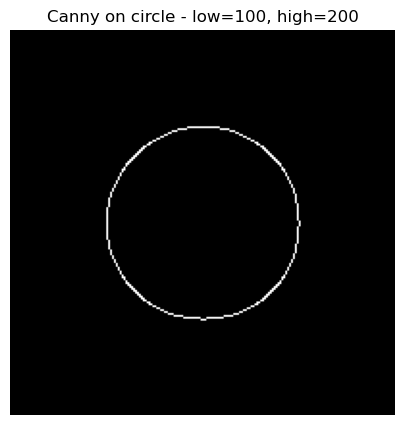

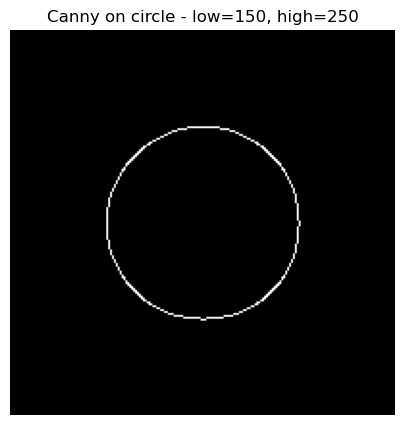

In [11]:
# Test several threshold pairs
pairs = [(30, 90), (50, 150), (100, 200), (150, 250)]

for low, high in pairs:
    edges = cv2.Canny(img_circle, low, high)
    show(edges, f"Canny on circle - low={low}, high={high}")

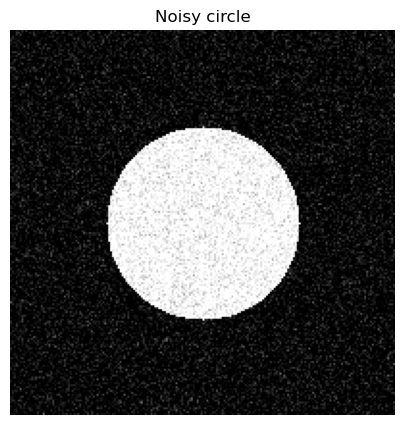

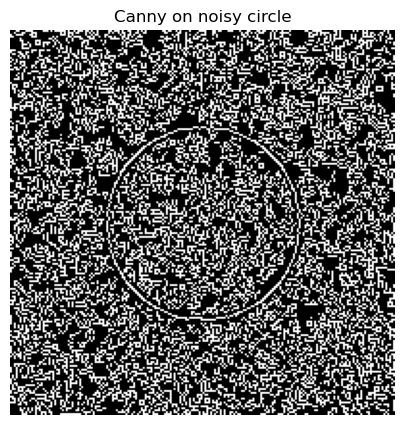

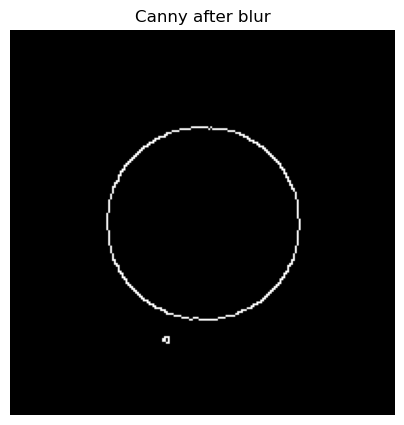

In [12]:
# Compare Canny on a noisy image
img_circle_noisy = np.clip(img_circle + rng.normal(0, 30, img_circle.shape), 0, 255).astype(np.uint8)

canny_noisy = cv2.Canny(img_circle_noisy, 50, 150)
canny_blurred = cv2.Canny(cv2.GaussianBlur(img_circle_noisy, (5, 5), 0), 50, 150)

show(img_circle_noisy, "Noisy circle")
show(canny_noisy, "Canny on noisy circle")
show(canny_blurred, "Canny after blur")

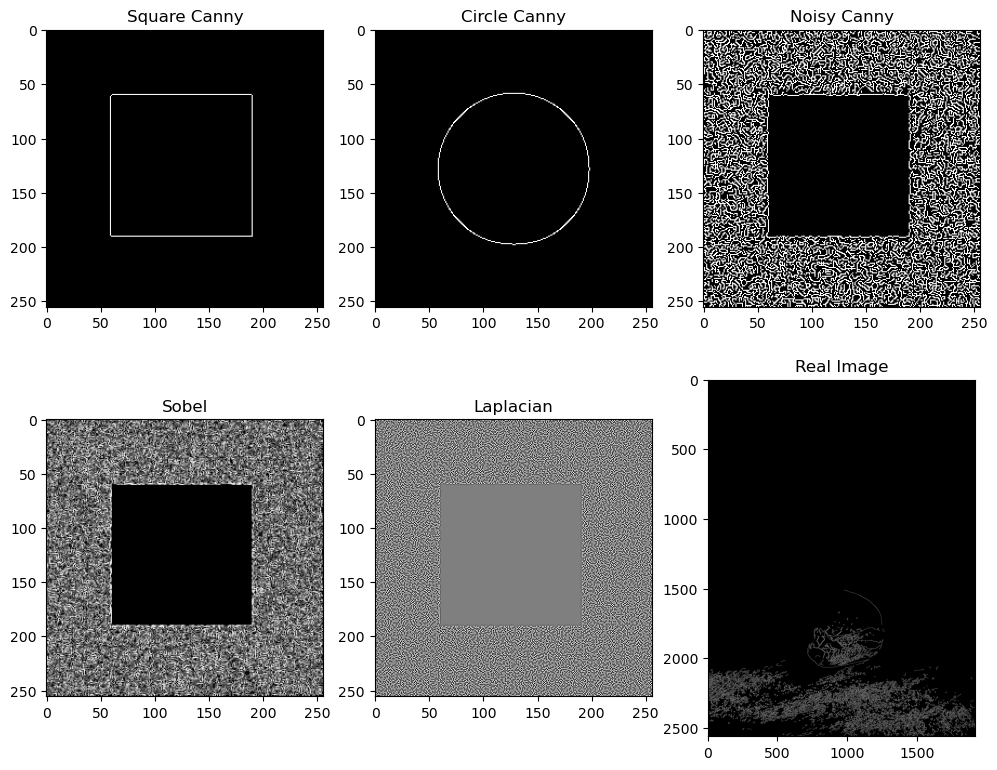

In [13]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# Function for running Canny
def run_canny(image, low, high, blur=False, ksize=5):
    img = image.copy()
    
    if blur:
        img = cv2.GaussianBlur(img, (ksize, ksize), 0)
        
    edges = cv2.Canny(img, low, high)
    return edges


# -------------------------

# -------------------------
square = np.zeros((256,256), dtype=np.uint8)
cv2.rectangle(square, (60,60), (190,190), 255, -1)

circle = np.zeros((256,256), dtype=np.uint8)
cv2.circle(circle, (128,128), 70, 255, -1)


# -------------------------

# -------------------------
noise = np.random.normal(0,25,square.shape).astype(np.uint8)
noisy_img = cv2.add(square, noise)

blurred_img = cv2.GaussianBlur(square,(11,11),0)



# -------------------------
thresholds = [(30,100),(50,150),(100,200),(150,250)]

results = []

for low, high in thresholds:
    edges = run_canny(square, low, high)
    results.append(edges)


# -------------------------

# -------------------------
sobelx = cv2.Sobel(noisy_img, cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(noisy_img, cv2.CV_64F,0,1,ksize=3)
sobel = cv2.magnitude(sobelx,sobely)

laplacian = cv2.Laplacian(noisy_img, cv2.CV_64F)

canny_noisy = run_canny(noisy_img,50,150,blur=True)


# -------------------------
t
# -------------------------
blur3 = run_canny(square,50,150,blur=True,ksize=3)
blur5 = run_canny(square,50,150,blur=True,ksize=5)
blur9 = run_canny(square,50,150,blur=True,ksize=9)


# -------------------------

# -------------------------
square_edges = run_canny(square,100,200)
circle_edges = run_canny(circle,100,200)


# -------------------------

# -------------------------
real = cv2.imread("ana_conda.jpg",0)
real_edges = run_canny(real,75,175,blur=True)


# -------------------------
# 
# -------------------------
plt.figure(figsize=(10,8))

plt.subplot(2,3,1); plt.imshow(square_edges,cmap="gray"); plt.title("Square Canny")
plt.subplot(2,3,2); plt.imshow(circle_edges,cmap="gray"); plt.title("Circle Canny")
plt.subplot(2,3,3); plt.imshow(canny_noisy,cmap="gray"); plt.title("Noisy Canny")

plt.subplot(2,3,4); plt.imshow(sobel,cmap="gray"); plt.title("Sobel")
plt.subplot(2,3,5); plt.imshow(laplacian,cmap="gray"); plt.title("Laplacian")
plt.subplot(2,3,6); plt.imshow(real_edges,cmap="gray"); plt.title("Real Image")

plt.tight_layout()
plt.show()